<a href="https://colab.research.google.com/github/heyRiddhima/Pytorch_Work/blob/main/KPI_Analysis_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install pandas numpy matplotlib seaborn scikit-learn "kagglehub[pandas-datasets]" torch jupyter

In [26]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
os.makedirs("images", exist_ok=True)
RESULTS = {}          # everything printed at the end comes from here

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"images/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [27]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# newer kagglehub versions renamed load_dataset -> dataset_load; support both
_load = getattr(kagglehub, "dataset_load", None) or kagglehub.load_dataset

df = _load(
    KaggleDatasetAdapter.PANDAS,
    "srikumarnayak/5g-network-kpi-dataset",   # owner/dataset
    "ds1_processed.csv",                      # file inside the dataset
)
df.head()

Using Colab cache for faster access to the '5g-network-kpi-dataset' dataset.


,timestamp,cell_id,cell_type,slice_type,throughput_mbps,latency_ms,packet_loss_pct,handover_count,rsrp_dbm,rsrq_db,...,throughput_mbps_norm,latency_ms_norm,packet_loss_pct_norm,handover_count_norm,rsrp_dbm_norm,rsrq_db_norm,prb_utilization_pct_norm,active_users_norm,throughput_per_user_norm,spectral_efficiency_norm
0,2024-01-01 00:00:00,CELL_007,micro,eMBB,864.50,6.418,0.4494,3,-97.3,-7.29,...,0.589857,0.147616,0.128942,0.250000,0.454,0.747647,0.473651,0.140,0.016532,0.459939
1,2024-01-01 00:01:00,CELL_020,micro,mMTC,48.97,29.693,0.5957,8,-104.8,-6.69,...,0.018870,0.791236,0.171078,0.666667,0.304,0.782941,0.213617,0.784,0.000106,0.030796
2,2024-01-01 00:02:00,CELL_015,macro,mMTC,53.18,10.869,0.3442,2,-103.8,-14.02,...,0.021818,0.270699,0.098644,0.166667,0.324,0.351765,0.252560,0.856,0.000105,0.030744
3,2024-01-01 00:03:00,CELL_011,macro,mMTC,62.44,25.479,0.5568,3,-87.2,-15.24,...,0.028301,0.674707,0.159875,0.250000,0.656,0.280000,0.185981,0.820,0.000144,0.045988
4,2024-01-01 00:04:00,CELL_008,micro,mMTC,43.89,21.725,0.6820,1,-91.6,-14.06,...,0.015313,0.570898,0.195933,0.083333,0.568,0.349412,0.069154,0.792,0.000087,0.044569


In [28]:
REQUIRED = ["timestamp", "cell_id", "cell_type", "slice_type", "throughput_mbps", "latency_ms",
            "packet_loss_pct", "handover_count", "rsrp_dbm", "rsrq_db", "prb_utilization_pct",
            "active_users", "sla_compliant", "hour_of_day", "is_peak_hour"]
missing = [c for c in REQUIRED if c not in df.columns]
assert not missing, f"Dataset is missing expected columns: {missing}"

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["violation"] = (1 - df["sla_compliant"]).astype(int)          # positive class = SLA violation
df["sla_status"] = np.where(df["violation"] == 1, "Violation", "Compliant")

SERVICE = ["throughput_mbps", "latency_ms", "packet_loss_pct"]
RADIO = ["rsrp_dbm", "rsrq_db", "prb_utilization_pct", "active_users", "handover_count"]

span = df["timestamp"].max() - df["timestamp"].min()
RESULTS["rows"] = int(len(df))
RESULTS["columns"] = int(df.shape[1])
RESULTS["cells"] = int(df["cell_id"].nunique())
RESULTS["slice_types"] = sorted(df["slice_type"].unique().tolist())
RESULTS["cell_types"] = sorted(df["cell_type"].unique().tolist())
RESULTS["span_days"] = round(span.total_seconds() / 86400, 2)
RESULTS["violation_rate_pct"] = round(100 * df["violation"].mean(), 2)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]} | Cells: {RESULTS['cells']} | "
      f"Slices: {RESULTS['slice_types']} | Cell types: {RESULTS['cell_types']}")
print(f"Period: {df['timestamp'].min()} -> {df['timestamp'].max()}  ({span})")
print(f"Missing values: {int(df.isna().sum().sum())} | Duplicate rows: {int(df.duplicated().sum())}")
print(f"SLA violation rate: {RESULTS['violation_rate_pct']}%  "
      f"(imbalance about 1:{(1 - df['violation'].mean()) / df['violation'].mean():.0f})")
display(df[SERVICE + RADIO].describe().T.round(2))

Rows: 5,000 | Columns: 32 | Cells: 20 | Slices: ['HC', 'URLLC', 'eMBB', 'mMTC'] | Cell types: ['macro', 'micro', 'pico']
Period: 2024-01-01 00:00:00 -> 2024-01-04 11:19:00  (3 days 11:19:00)
Missing values: 0 | Duplicate rows: 0
SLA violation rate: 6.44%  (imbalance about 1:15)


,count,mean,std,min,25%,50%,75%,max
throughput_mbps,5000.0,533.77,399.14,22.02,191.40,528.76,858.74,1450.30
latency_ms,5000.0,9.30,8.81,1.08,2.21,7.20,10.68,37.24
packet_loss_pct,5000.0,0.47,0.67,0.00,0.05,0.18,0.58,3.47
rsrp_dbm,5000.0,-94.91,14.49,-120.00,-107.50,-94.60,-82.60,-70.00
rsrq_db,5000.0,-11.51,4.93,-20.00,-15.87,-11.37,-7.30,-3.00
prb_utilization_pct,5000.0,60.21,18.27,18.50,48.10,60.70,73.80,98.10
active_users,5000.0,62.30,70.63,1.00,12.00,41.00,53.00,251.00
handover_count,5000.0,3.05,1.77,0.00,2.00,3.00,4.00,12.00


In [29]:
gaps = (df.sort_values(["cell_id", "timestamp"]).groupby("cell_id")["timestamp"].diff()
          .dt.total_seconds().div(60).dropna())
RESULTS["median_gap_same_cell_min"] = round(float(gaps.median()), 1)
print(f"Median gap between consecutive samples of the SAME cell: {gaps.median():.0f} min "
      f"(5th-95th pct: {gaps.quantile(.05):.0f}-{gaps.quantile(.95):.0f} min)")
print("-> Each cell is sampled sparsely and irregularly, so 'last 60 samples' is NOT 'last 60 minutes'.")

Median gap between consecutive samples of the SAME cell: 14 min (5th-95th pct: 1-60 min)
-> Each cell is sampled sparsely and irregularly, so 'last 60 samples' is NOT 'last 60 minutes'.


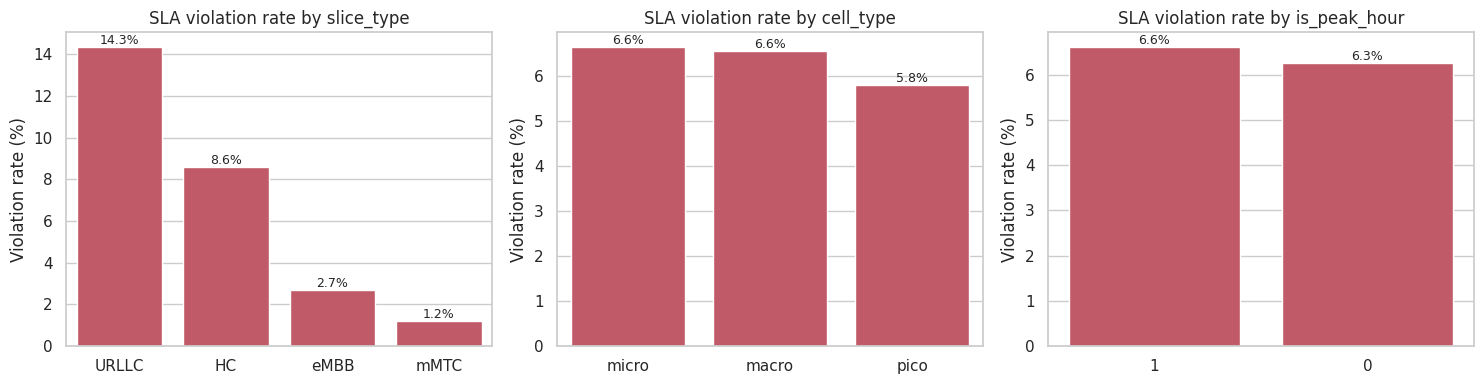

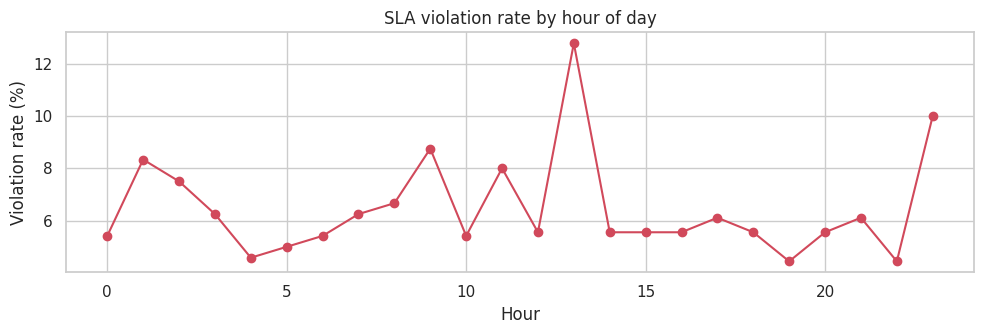

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["slice_type", "cell_type", "is_peak_hour"]):
    t = (df.groupby(col)["violation"].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=t.index.astype(str), y=t.values, ax=ax, color="#D1495B")
    ax.set_title(f"SLA violation rate by {col}")
    ax.set_ylabel("Violation rate (%)"); ax.set_xlabel("")
    for i, v in enumerate(t.values):
        ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    RESULTS[f"violation_rate_by_{col}_pct"] = {str(k): round(float(v), 2) for k, v in t.items()}
savefig("01_violation_rate_by_group")

by_hour = df.groupby("hour_of_day")["violation"].mean() * 100
plt.figure(figsize=(10, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o", color="#D1495B")
plt.title("SLA violation rate by hour of day"); plt.xlabel("Hour"); plt.ylabel("Violation rate (%)")
savefig("02_violation_rate_by_hour")
RESULTS["worst_hour"] = int(by_hour.idxmax())

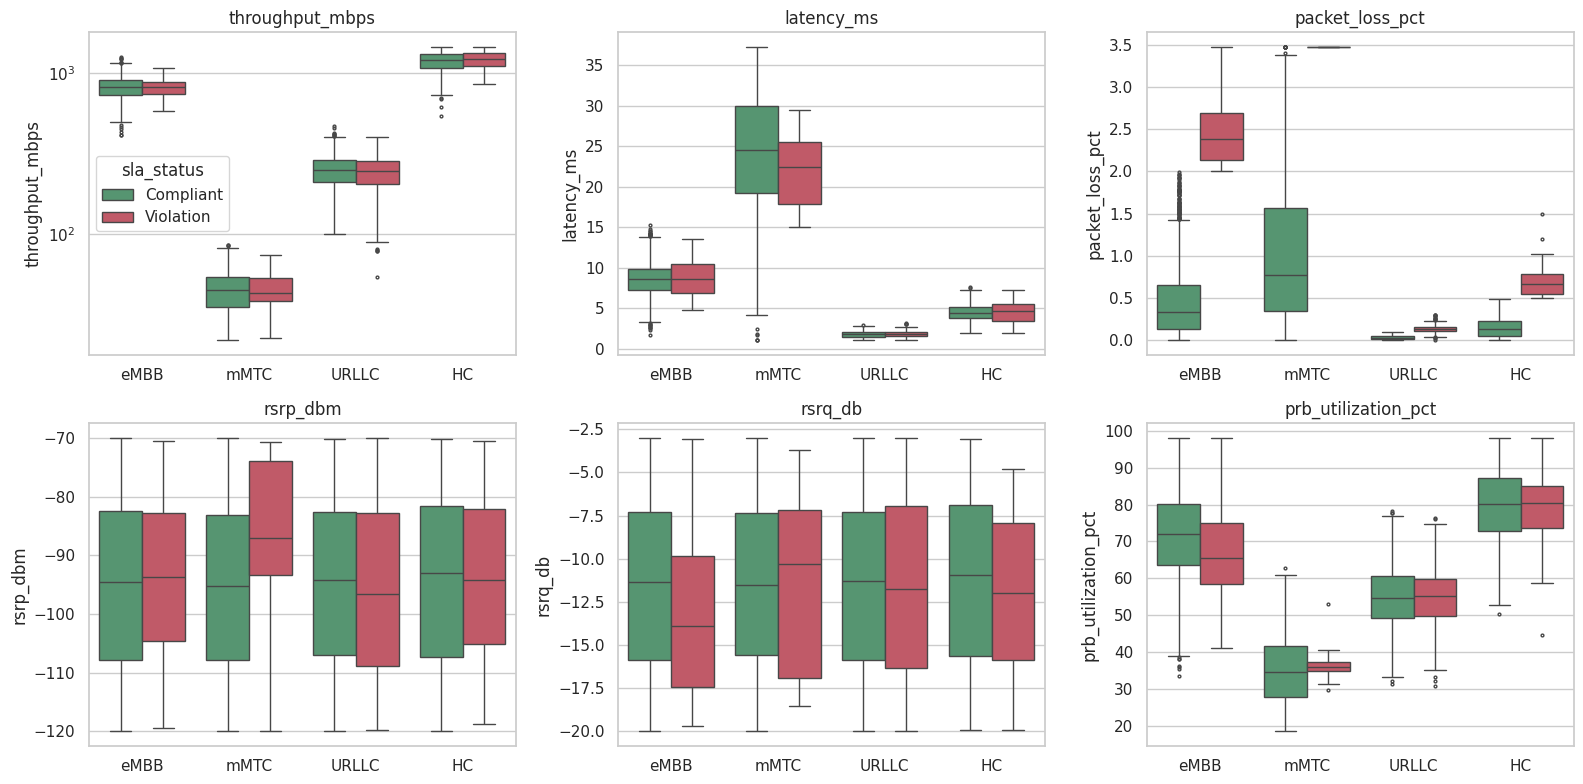

In [31]:
palette = {"Compliant": "#4C9F70", "Violation": "#D1495B"}
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), SERVICE + ["rsrp_dbm", "rsrq_db", "prb_utilization_pct"]):
    sns.boxplot(data=df, x="slice_type", y=col, hue="sla_status", palette=palette, ax=ax, fliersize=2)
    if col == "throughput_mbps":
        ax.set_yscale("log")
    ax.set_title(col); ax.set_xlabel("")
    if ax is not axes[0, 0]:
        ax.get_legend().remove()
savefig("03_kpi_by_slice_and_sla")

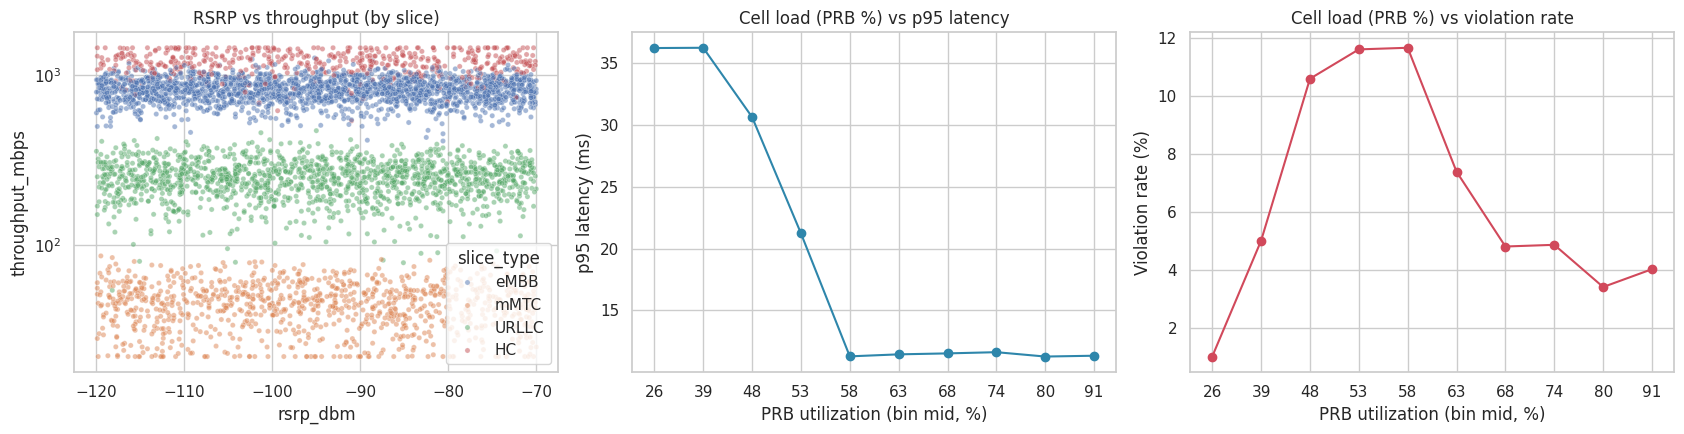

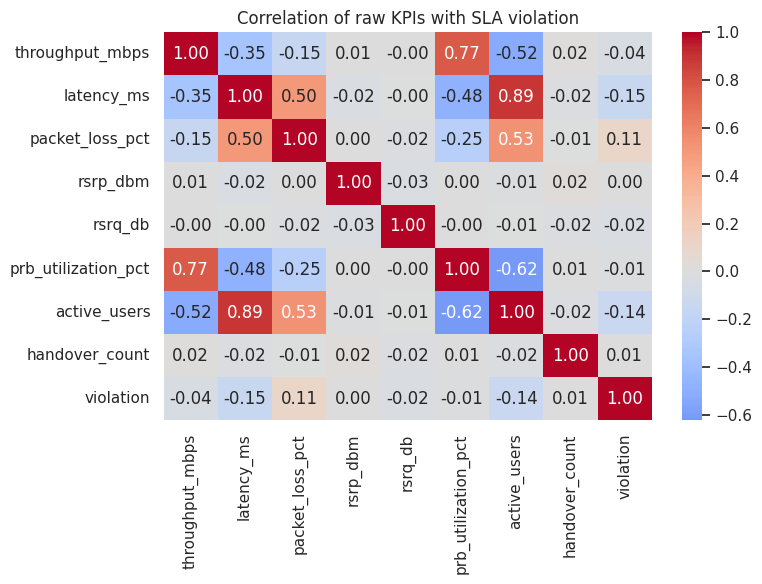

Strongest linear correlations with violation: {'latency_ms': -0.154, 'active_users': -0.143, 'packet_loss_pct': 0.105}


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.scatterplot(data=df, x="rsrp_dbm", y="throughput_mbps", hue="slice_type", alpha=.5, s=14, ax=axes[0])
axes[0].set_yscale("log"); axes[0].set_title("RSRP vs throughput (by slice)")

df["prb_decile"] = pd.qcut(df["prb_utilization_pct"], 10, duplicates="drop")
g = df.groupby("prb_decile", observed=True).agg(p95_latency=("latency_ms", lambda s: s.quantile(.95)),
                                                violation_rate=("violation", "mean"))
x = [f"{i.mid:.0f}" for i in g.index]
axes[1].plot(x, g["p95_latency"], marker="o", color="#2E86AB")
axes[1].set_title("Cell load (PRB %) vs p95 latency"); axes[1].set_xlabel("PRB utilization (bin mid, %)")
axes[1].set_ylabel("p95 latency (ms)")
axes[2].plot(x, g["violation_rate"] * 100, marker="o", color="#D1495B")
axes[2].set_title("Cell load (PRB %) vs violation rate"); axes[2].set_xlabel("PRB utilization (bin mid, %)")
axes[2].set_ylabel("Violation rate (%)")
savefig("04_radio_vs_service")

corr = df[SERVICE + RADIO + ["violation"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of raw KPIs with SLA violation")
savefig("05_correlation")
RESULTS["top_corr_with_violation"] = {k: round(float(v), 3) for k, v in
    corr["violation"].drop("violation").sort_values(key=abs, ascending=False).head(3).items()}
print("Strongest linear correlations with violation:", RESULTS["top_corr_with_violation"])

,samples,violations,violation_rate_pct,avg_prb,avg_rsrp
cell_id,,,,,
CELL_016,221,22,9.95,58.51,-95.66
CELL_006,243,22,9.05,60.96,-95.39
CELL_001,241,21,8.71,59.63,-93.32
CELL_005,256,22,8.59,59.10,-95.39
CELL_004,259,20,7.72,61.67,-93.97
CELL_018,231,17,7.36,57.70,-95.83
CELL_017,299,22,7.36,59.66,-94.52
CELL_013,273,19,6.96,61.07,-94.91
CELL_019,251,17,6.77,60.28,-94.17


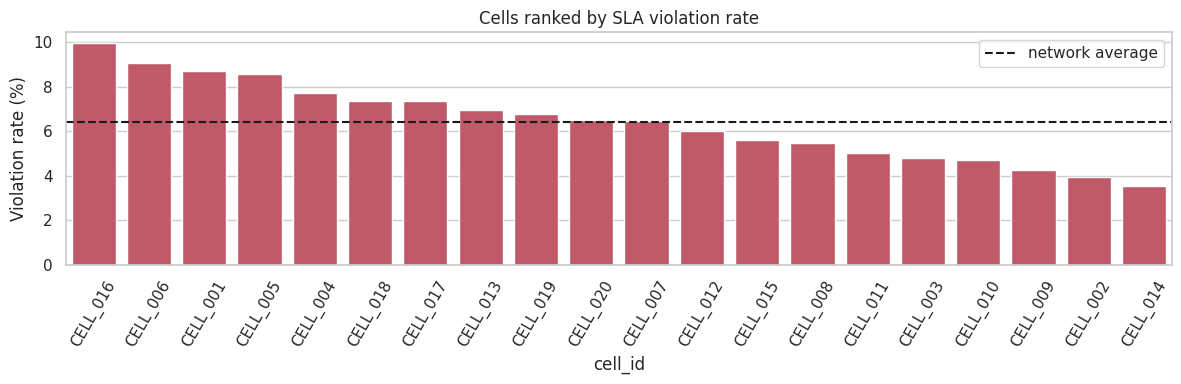

In [33]:
cell_stats = (df.groupby("cell_id").agg(samples=("violation", "size"), violations=("violation", "sum"),
                                         violation_rate_pct=("violation", lambda s: 100 * s.mean()),
                                         avg_prb=("prb_utilization_pct", "mean"),
                                         avg_rsrp=("rsrp_dbm", "mean"))
                .sort_values("violation_rate_pct", ascending=False).round(2))
display(cell_stats)

plt.figure(figsize=(12, 4))
sns.barplot(x=cell_stats.index, y=cell_stats["violation_rate_pct"], color="#D1495B")
plt.axhline(df["violation"].mean() * 100, color="k", ls="--", label="network average")
plt.xticks(rotation=60); plt.ylabel("Violation rate (%)"); plt.title("Cells ranked by SLA violation rate")
plt.legend()
savefig("06_cell_ranking")
RESULTS["worst_cells"] = cell_stats.head(3)["violation_rate_pct"].to_dict()

In [34]:
X_rule = pd.get_dummies(df[SERVICE + ["slice_type"]], columns=["slice_type"], dtype=float)
y_rule = df["violation"].values
cut = int(0.8 * len(df))

sweep = []
for depth in range(1, 7):
    t = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=SEED)
    t.fit(X_rule.iloc[:cut], y_rule[:cut])
    p = t.predict(X_rule.iloc[cut:])
    sweep.append({"depth": depth,
                  "holdout_precision": precision_score(y_rule[cut:], p, zero_division=0),
                  "holdout_recall": recall_score(y_rule[cut:], p, zero_division=0),
                  "holdout_f1": f1_score(y_rule[cut:], p, zero_division=0)})
sweep = pd.DataFrame(sweep).round(3)
display(sweep)

# smallest depth within 0.01 F1 of the best -> simplest rule that explains the label
best_f1 = sweep["holdout_f1"].max()
depth_star = int(sweep[sweep["holdout_f1"] >= best_f1 - 0.01]["depth"].min())
rule_tree = DecisionTreeClassifier(max_depth=depth_star, class_weight="balanced", random_state=SEED)
rule_tree.fit(X_rule.iloc[:cut], y_rule[:cut])
print(f"Chosen depth: {depth_star}\n")
print(export_text(rule_tree, feature_names=list(X_rule.columns)))

row = sweep[sweep["depth"] == depth_star].iloc[0]
RESULTS["sla_rule"] = {"tree_depth": depth_star, "holdout_precision": float(row["holdout_precision"]),
                       "holdout_recall": float(row["holdout_recall"]), "holdout_f1": float(row["holdout_f1"])}

,depth,holdout_precision,holdout_recall,holdout_f1
0,1,0.085,0.964,0.157
1,2,0.740,0.673,0.705
2,3,0.485,0.873,0.623
3,4,0.396,1.000,0.567
4,5,0.821,1.000,0.902
5,6,0.833,1.000,0.909


Chosen depth: 5

|--- packet_loss_pct <= 0.10
|   |--- throughput_mbps <= 96.47
|   |   |--- slice_type_URLLC <= 0.50
|   |   |   |--- class: 0
|   |   |--- slice_type_URLLC >  0.50
|   |   |   |--- class: 1
|   |--- throughput_mbps >  96.47
|   |   |--- latency_ms <= 3.03
|   |   |   |--- class: 0
|   |   |--- latency_ms >  3.03
|   |   |   |--- throughput_mbps <= 420.73
|   |   |   |   |--- class: 1
|   |   |   |--- throughput_mbps >  420.73
|   |   |   |   |--- slice_type_eMBB <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- slice_type_eMBB >  0.50
|   |   |   |   |   |--- class: 0
|--- packet_loss_pct >  0.10
|   |--- latency_ms <= 3.48
|   |   |--- slice_type_URLLC <= 0.50
|   |   |   |--- packet_loss_pct <= 0.49
|   |   |   |   |--- slice_type_HC <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- slice_type_HC >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- packet_loss_pct >  0.49
|   |   |   |   |--- slice_type_HC <= 0.50
|   |   |   |   |   

In [35]:
num_cols = ["rsrp_dbm", "rsrq_db", "prb_utilization_pct", "active_users", "handover_count",
            "hour_of_day", "is_peak_hour"]
cat_cols = ["slice_type", "cell_type"]
X_all = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, dtype=float).astype(float)
y_all = df["violation"].values

n = len(df); i_tr, i_va = int(.6 * n), int(.8 * n)
Xtr, Xva, Xte = X_all.iloc[:i_tr], X_all.iloc[i_tr:i_va], X_all.iloc[i_va:]
ytr, yva, yte = y_all[:i_tr], y_all[i_tr:i_va], y_all[i_va:]
for name, y_ in [("train", ytr), ("val", yva), ("test", yte)]:
    print(f"{name:5s}: {len(y_):5d} rows, {int(y_.sum()):4d} violations ({100 * y_.mean():.2f}%)")
assert min(ytr.sum(), yva.sum(), yte.sum()) > 0, "A split has no violations; adjust split sizes."

models = {
    "Dummy (base rate)": DummyClassifier(strategy="prior"),
    "Logistic Regression": make_pipeline(StandardScaler(),
                                         LogisticRegression(class_weight="balanced", max_iter=2000)),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, n_jobs=-1,
                                            class_weight="balanced_subsample", random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(class_weight="balanced", max_depth=4,
                                                        learning_rate=0.05, max_iter=200, random_state=SEED),
}
rows, probs = [], {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    pv, pt = m.predict_proba(Xva)[:, 1], m.predict_proba(Xte)[:, 1]
    probs[name] = (pv, pt)
    rows.append({"model": name,
                 "val_PR_AUC": average_precision_score(yva, pv), "val_ROC_AUC": roc_auc_score(yva, pv),
                 "test_PR_AUC": average_precision_score(yte, pt), "test_ROC_AUC": roc_auc_score(yte, pt)})
leaderboard = pd.DataFrame(rows).set_index("model").round(3)
print(f"\nBase rate (a random model's PR-AUC): val={yva.mean():.3f}  test={yte.mean():.3f}")
display(leaderboard)

train:  3000 rows,  200 violations (6.67%)
val  :  1000 rows,   67 violations (6.70%)
test :  1000 rows,   55 violations (5.50%)

Base rate (a random model's PR-AUC): val=0.067  test=0.055


,val_PR_AUC,val_ROC_AUC,test_PR_AUC,test_ROC_AUC
model,,,,
Dummy (base rate),0.067,0.500,0.055,0.500
Logistic Regression,0.148,0.736,0.128,0.774
Random Forest,0.134,0.725,0.151,0.755
Gradient Boosting,0.155,0.718,0.120,0.709


Best model: Gradient Boosting   (alert threshold tuned on validation = 0.536)
TEST  precision=0.134  recall=0.509  F1=0.212  PR-AUC=0.120  ROC-AUC=0.709
Alerts raised on 20.9% of test samples; top-10% risk bucket captures 23.6% of violations (lift 2.4x)
Time-series CV PR-AUC: 0.118 +/- 0.016 over 5 folds (base rate 0.064)


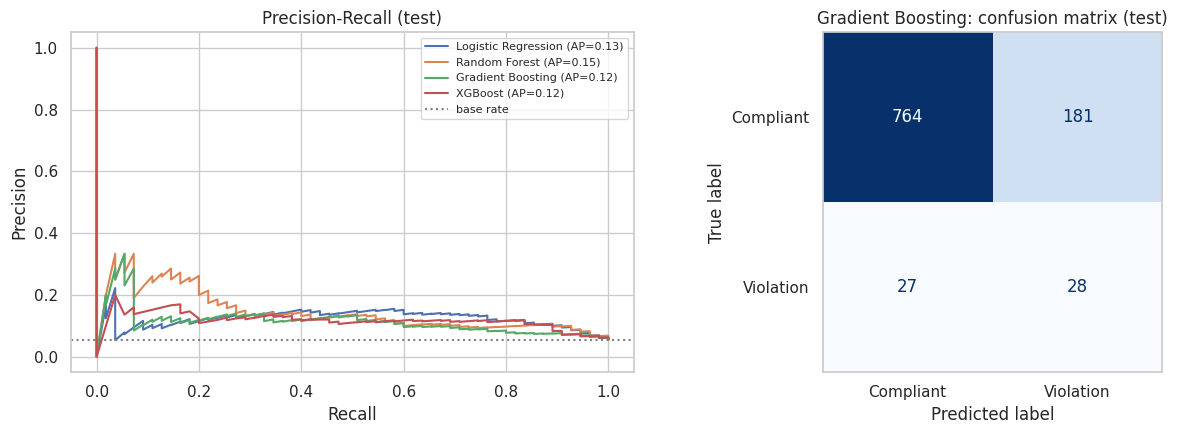

In [37]:
cand = leaderboard.drop(index="Dummy (base rate)")
best_name = cand["val_PR_AUC"].idxmax()
best_model = models[best_name]
pv, pt = probs[best_name]

prec, rec, thr = precision_recall_curve(yva, pv)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
thr_star = float(thr[np.argmax(f1s)])

pred = (pt >= thr_star).astype(int)
test_prec = precision_score(yte, pred, zero_division=0)
test_rec = recall_score(yte, pred, zero_division=0)
test_f1 = f1_score(yte, pred, zero_division=0)
flag_rate = pred.mean()

# lift: how many violations sit in the top-10% highest-risk samples?
top_k = max(1, int(0.10 * len(pt)))
captured = yte[np.argsort(-pt)[:top_k]].sum() / yte.sum()

# robustness: expanding-window time-series CV on the whole timeline
cv_scores = []
for tr_idx, te_idx in TimeSeriesSplit(n_splits=5).split(X_all):
    if y_all[te_idx].sum() == 0 or y_all[tr_idx].sum() == 0:
        continue
    mdl = clone(best_model).fit(X_all.iloc[tr_idx], y_all[tr_idx])
    cv_scores.append(average_precision_score(y_all[te_idx], mdl.predict_proba(X_all.iloc[te_idx])[:, 1]))

print(f"Best model: {best_name}   (alert threshold tuned on validation = {thr_star:.3f})")
print(f"TEST  precision={test_prec:.3f}  recall={test_rec:.3f}  F1={test_f1:.3f}  "
      f"PR-AUC={leaderboard.loc[best_name, 'test_PR_AUC']:.3f}  ROC-AUC={leaderboard.loc[best_name, 'test_ROC_AUC']:.3f}")
print(f"Alerts raised on {100 * flag_rate:.1f}% of test samples; top-10% risk bucket captures "
      f"{100 * captured:.1f}% of violations (lift {captured / 0.10:.1f}x)")
print(f"Time-series CV PR-AUC: {np.mean(cv_scores):.3f} +/- {np.std(cv_scores):.3f} over {len(cv_scores)} folds "
      f"(base rate {y_all.mean():.3f})")

RESULTS["classifier"] = {
    "best_model": best_name, "threshold": thr_star,
    "test_base_rate": float(yte.mean()),
    "test_pr_auc": float(leaderboard.loc[best_name, "test_PR_AUC"]),
    "test_roc_auc": float(leaderboard.loc[best_name, "test_ROC_AUC"]),
    "test_precision": float(test_prec), "test_recall": float(test_rec), "test_f1": float(test_f1),
    "alert_rate": float(flag_rate), "top10_capture": float(captured), "top10_lift": float(captured / 0.10),
    "cv_pr_auc_mean": float(np.mean(cv_scores)), "cv_pr_auc_std": float(np.std(cv_scores)),
    "cv_folds": len(cv_scores),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, (_, p_te) in probs.items():
    if name.startswith("Dummy"):
        continue                      # a constant predictor has no meaningful PR curve
    pr, rc, _ = precision_recall_curve(yte, p_te)
    axes[0].plot(rc, pr, label=f"{name} (AP={average_precision_score(yte, p_te):.2f})")
axes[0].axhline(yte.mean(), color="gray", ls=":", label="base rate")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("Precision-Recall (test)")
axes[0].legend(fontsize=8)
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=["Compliant", "Violation"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"{best_name}: confusion matrix (test)"); axes[1].grid(False)
savefig("07_classifier_results")

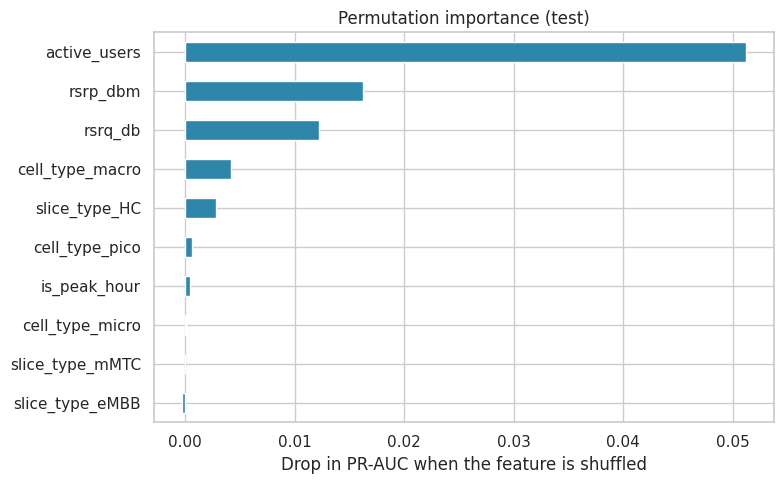

Top drivers: {'active_users': 0.0512, 'rsrp_dbm': 0.0162, 'rsrq_db': 0.0122}


In [38]:
pi = permutation_importance(best_model, Xte, yte, scoring="average_precision",
                            n_repeats=20, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=Xte.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
imp.head(10).sort_values().plot.barh(color="#2E86AB")
plt.xlabel("Drop in PR-AUC when the feature is shuffled"); plt.title("Permutation importance (test)")
savefig("08_permutation_importance")
RESULTS["top_features"] = {k: round(float(v), 4) for k, v in imp.head(3).items()}
print("Top drivers:", RESULTS["top_features"])

In [39]:
RUN_LSTM = True        # set False to skip
try:
    if not RUN_LSTM:
        raise RuntimeError("skipped by user")
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    torch.manual_seed(SEED)
    NORM = ["throughput_mbps_norm", "latency_ms_norm", "packet_loss_pct_norm", "rsrp_dbm_norm", "rsrq_db_norm"]
    W = 10    # 10 past samples of the same cell

    def make_seq(v, w):
        return (np.array([v[i:i + w] for i in range(len(v) - w)], dtype=np.float32),
                np.array([v[i + w] for i in range(len(v) - w)], dtype=np.float32))

    tr_X, tr_y, va_X, va_y, te_X, te_y = [], [], [], [], [], []
    for cid, g in df.sort_values("timestamp").groupby("cell_id"):
        v = g[NORM].values.astype(np.float32)
        if len(v) < 3 * W:
            continue
        cut = int(.8 * len(v))
        Xa, ya = make_seq(v[:cut], W)                 # training windows
        Xb, yb = make_seq(v[cut - W:], W)             # test windows: context from train, targets from test period
        k = int(.9 * len(Xa))
        tr_X.append(Xa[:k]); tr_y.append(ya[:k]); va_X.append(Xa[k:]); va_y.append(ya[k:])
        te_X.append(Xb);     te_y.append(yb)
    tr_X, tr_y, va_X, va_y, te_X, te_y = [np.concatenate(a) for a in (tr_X, tr_y, va_X, va_y, te_X, te_y)]
    print("sequences  train/val/test:", len(tr_X), len(va_X), len(te_X))

    class LSTMNet(nn.Module):
        def __init__(self, n_feat=5, hidden=32):
            super().__init__()
            self.lstm = nn.LSTM(n_feat, hidden, batch_first=True)
            self.fc = nn.Linear(hidden, n_feat)
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1])

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = LSTMNet().to(dev)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.tensor(tr_X), torch.tensor(tr_y)), batch_size=64, shuffle=True)
    Xv, yv = torch.tensor(va_X).to(dev), torch.tensor(va_y).to(dev)

    best_val, best_state, patience = np.inf, None, 0
    for epoch in range(60):
        net.train()
        for xb, yb in loader:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad(); loss_fn(net(xb), yb).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            val = loss_fn(net(Xv), yv).item()
        if val < best_val - 1e-5:
            best_val, best_state, patience = val, {k: t.clone() for k, t in net.state_dict().items()}, 0
        else:
            patience += 1
            if patience >= 6:
                break
    net.load_state_dict(best_state); net.eval()
    with torch.no_grad():
        lstm_pred = net(torch.tensor(te_X).to(dev)).cpu().numpy()

    mse_lstm = float(np.mean((te_y - lstm_pred) ** 2))
    mse_mean = float(np.mean((te_y - tr_y.mean(0)) ** 2))
    mse_persist = float(np.mean((te_y - te_X[:, -1, :]) ** 2))
    table = pd.DataFrame({"test_MSE": {"Predict training mean": mse_mean,
                                       "Persistence (repeat last value)": mse_persist,
                                       "LSTM": mse_lstm}}).round(4)
    display(table)
    gain = 100 * (1 - mse_lstm / mse_mean)
    beats = mse_lstm < min(mse_mean, mse_persist) * 0.98
    print(f"LSTM vs mean baseline: {gain:+.1f}% MSE change ->",
          "LSTM adds real predictive value." if beats else
          "LSTM does NOT meaningfully beat trivial baselines: KPI samples carry little temporal structure.")
    RESULTS["lstm"] = {"mse_lstm": mse_lstm, "mse_mean": mse_mean, "mse_persistence": mse_persist,
                       "gain_vs_mean_pct": float(gain), "beats_baselines": bool(beats)}
except Exception as e:                    # no torch / skipped / any failure: never break Run All
    print(f"LSTM experiment not run ({type(e).__name__}: {e})")
    RESULTS["lstm"] = None

sequences  train/val/test: 3405 386 1009


,test_MSE
Predict training mean,0.0697
Persistence (repeat last value),0.1391
LSTM,0.0698


LSTM vs mean baseline: -0.1% MSE change -> LSTM does NOT meaningfully beat trivial baselines: KPI samples carry little temporal structure.


In [42]:
rf_kw = dict(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1)
slice_dummies = pd.get_dummies(df["slice_type"], prefix="slice", dtype=float)
groups = {
    "Radio only":                df[RADIO],
    "Service KPIs only":         df[SERVICE],
    "Service KPIs + slice":      pd.concat([df[SERVICE], slice_dummies], axis=1),
    "All features":              pd.concat([df[SERVICE + RADIO], slice_dummies], axis=1),
}
cut = int(0.8 * len(df))                              # time-ordered split
y_tr, y_te = df["violation"].iloc[:cut], df["violation"].iloc[cut:]
rows = []
for name, X in groups.items():
    m = RandomForestClassifier(**rf_kw).fit(X.iloc[:cut], y_tr)
    p, s = m.predict(X.iloc[cut:]), m.predict_proba(X.iloc[cut:])[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, p).ravel()
    rows.append({"features": name,
                 "violation_precision": precision_score(y_te, p, zero_division=0),
                 "violation_recall": recall_score(y_te, p),
                 "violation_F1": f1_score(y_te, p),
                 "PR_AUC": average_precision_score(y_te, s),
                 "missed_violations": f"{fn} of {fn + tp}"})
ablation = pd.DataFrame(rows).round(3)
display(ablation)
print(f"Base rate of violations in test: {y_te.mean():.3f}")
savefig_name = "09_ablation_table"
ablation.to_csv("ablation_results.csv", index=False)

,features,violation_precision,violation_recall,violation_F1,PR_AUC,missed_violations
0,Radio only,0.000,0.000,0.000,0.097,55 of 55
1,Service KPIs only,0.963,0.945,0.954,0.990,3 of 55
2,Service KPIs + slice,0.964,0.982,0.973,0.997,1 of 55
3,All features,0.981,0.945,0.963,0.994,3 of 55


Base rate of violations in test: 0.055


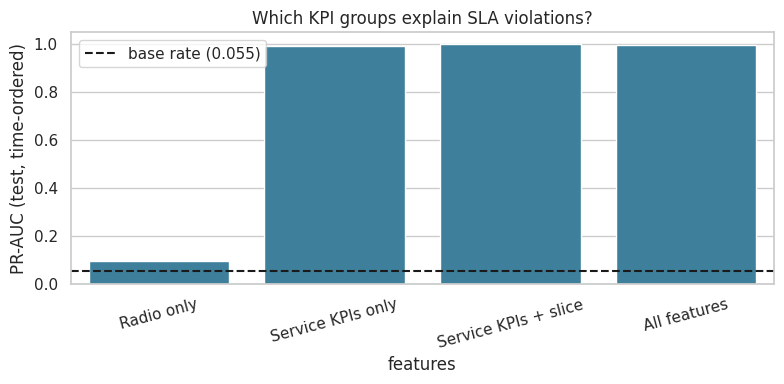

In [43]:
plt.figure(figsize=(8, 4))
sns.barplot(data=ablation, x="features", y="PR_AUC", color="#2E86AB")
plt.axhline(y_te.mean(), color="k", ls="--", label=f"base rate ({y_te.mean():.3f})")
plt.xticks(rotation=15); plt.ylabel("PR-AUC (test, time-ordered)")
plt.title("Which KPI groups explain SLA violations?"); plt.legend()
savefig("09_ablation")